# Lecture 4: Exploratory Data Analysis
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Conduct a structured EDA on a real dataset
2. Handle missing values and outliers
3. Analyse distributions and relationships
4. Generate insights to guide modelling decisions

In [1]:
# Install if running on Colab: !pip install -q pandas matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
print('Ready.')

Ready.


## 4.1 Loading a Real Dataset

We use the Student Performance dataset from UCI ML Repository.

In [2]:
# Download UCI Student Performance dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
import urllib.request, zipfile, io
try:
    response = urllib.request.urlopen(url, timeout=10)
    zf = zipfile.ZipFile(io.BytesIO(response.read()))
    df = pd.read_csv(zf.open('student-mat.csv'), sep=';')
    print('Dataset downloaded successfully.')
except Exception:
    print('Download failed. Generating synthetic equivalent...')
    np.random.seed(42)
    n = 395
    df = pd.DataFrame({
        'age': np.random.randint(15, 22, n),
        'studytime': np.random.randint(1, 5, n),
        'absences': np.random.poisson(4, n),
        'G1': np.random.randint(5, 19, n),
        'G2': np.random.randint(5, 19, n),
        'G3': np.random.randint(0, 20, n),
        'sex': np.random.choice(['M', 'F'], n),
        'address': np.random.choice(['U', 'R'], n),
        'Medu': np.random.randint(0, 5, n),
        'failures': np.random.randint(0, 4, n)
    })
    # Introduce realistic missing values
    for col in ['G1', 'absences']:
        df.loc[df.sample(frac=0.05).index, col] = np.nan
    print('Synthetic dataset created.')

print(f'Shape: {df.shape}')

Download failed. Generating synthetic equivalent...
Synthetic dataset created.
Shape: (395, 10)


In [3]:
# Step 1: Basic structure
print('=== Dataset Info ===')
df.info()
print('\n=== First 5 rows ===')
df.head()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        395 non-null    int32  
 1   studytime  395 non-null    int32  
 2   absences   375 non-null    float64
 3   G1         375 non-null    float64
 4   G2         395 non-null    int32  
 5   G3         395 non-null    int32  
 6   sex        395 non-null    object 
 7   address    395 non-null    object 
 8   Medu       395 non-null    int32  
 9   failures   395 non-null    int32  
dtypes: float64(2), int32(6), object(2)
memory usage: 21.7+ KB

=== First 5 rows ===


,age,studytime,absences,G1,G2,G3,sex,address,Medu,failures
0,21,2,8.0,11.0,8,19,F,R,1,3
1,18,1,3.0,8.0,8,19,F,U,2,2
2,19,4,7.0,9.0,6,2,F,R,3,1
3,21,3,4.0,12.0,7,2,M,R,3,1
4,17,4,5.0,NaN,17,16,F,R,0,1


In [4]:
# Step 2: Summary statistics
df.describe()

,age,studytime,absences,G1,G2,G3,Medu,failures
count,395.000000,395.000000,375.000000,375.000000,395.000000,395.000000,395.000000,395.000000
mean,17.954430,2.473418,3.960000,11.290667,11.653165,9.691139,1.977215,1.544304
std,2.012133,1.158144,1.891721,4.164183,3.902194,6.045580,1.446855,1.092167
min,15.000000,1.000000,0.000000,5.000000,5.000000,0.000000,0.000000,0.000000
25%,16.000000,1.000000,3.000000,7.000000,8.000000,4.000000,1.000000,1.000000
50%,18.000000,2.000000,4.000000,11.000000,12.000000,9.000000,2.000000,2.000000
75%,20.000000,4.000000,5.000000,15.000000,15.000000,15.000000,3.000000,2.500000
max,21.000000,4.000000,10.000000,18.000000,18.000000,19.000000,4.000000,3.000000


In [5]:
# Step 3: Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0])

          Missing Count  Missing %
absences             20       5.06
G1                   20       5.06


## 4.2 Handling Missing Values

In [6]:
# Impute numerical columns with median
num_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])
print('After imputation:')
print(df.isnull().sum().sum(), 'missing values remaining')

After imputation:
0 missing values remaining


## 4.3 Distribution Analysis

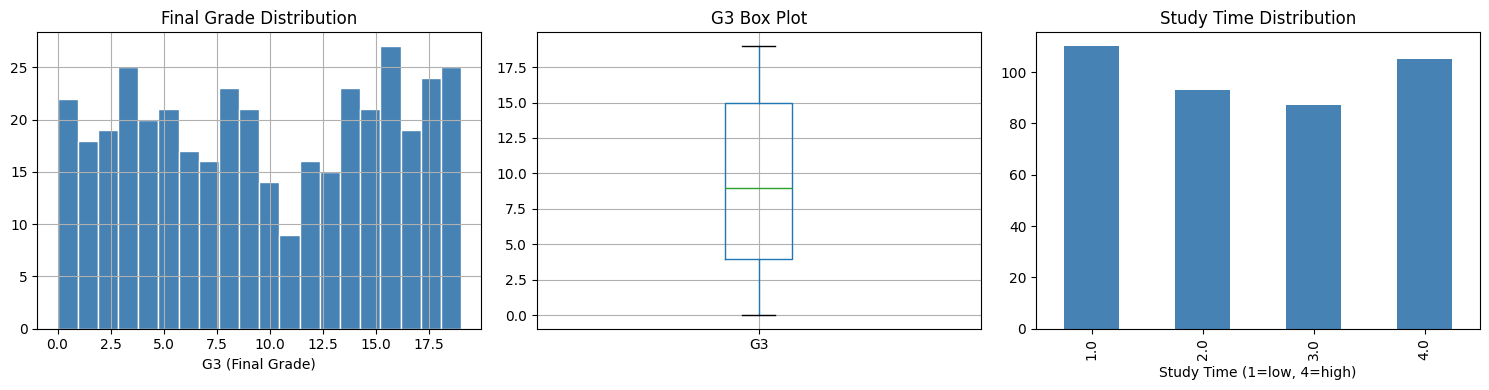

In [7]:
# Target variable: G3 (final grade)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['G3'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Final Grade Distribution')
axes[0].set_xlabel('G3 (Final Grade)')

# Box plot
df.boxplot(column='G3', ax=axes[1])
axes[1].set_title('G3 Box Plot')

# Study time
df['studytime'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Study Time Distribution')
axes[2].set_xlabel('Study Time (1=low, 4=high)')

plt.tight_layout()
plt.show()

## 4.4 Outlier Detection (IQR Method)

In [8]:
col = 'absences'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'Outlier bounds for "{col}": lower={lower:.1f}, upper={upper:.1f}')
print(f'Number of outliers: {len(outliers)}')
print(f'Max absences in dataset: {df[col].max():.0f}')

Outlier bounds for "absences": lower=0.0, upper=8.0
Number of outliers: 5
Max absences in dataset: 10


## 4.5 Relationship Analysis

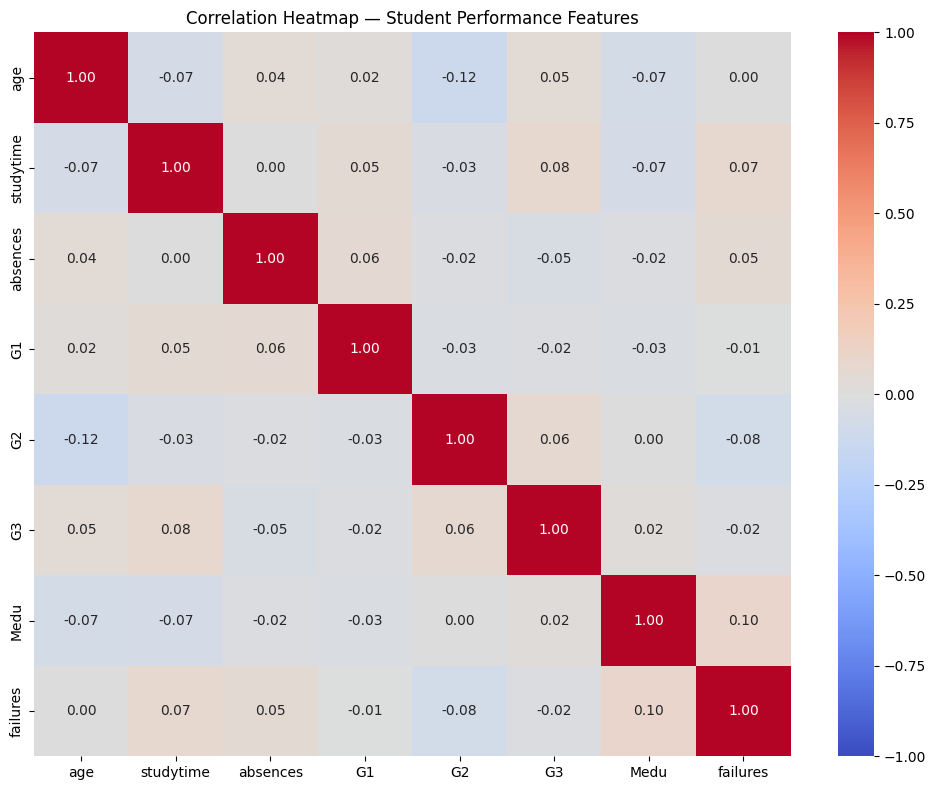

In [9]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Student Performance Features')
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_25500\746463090.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='G3', ax=axes[1], palette='Set2')


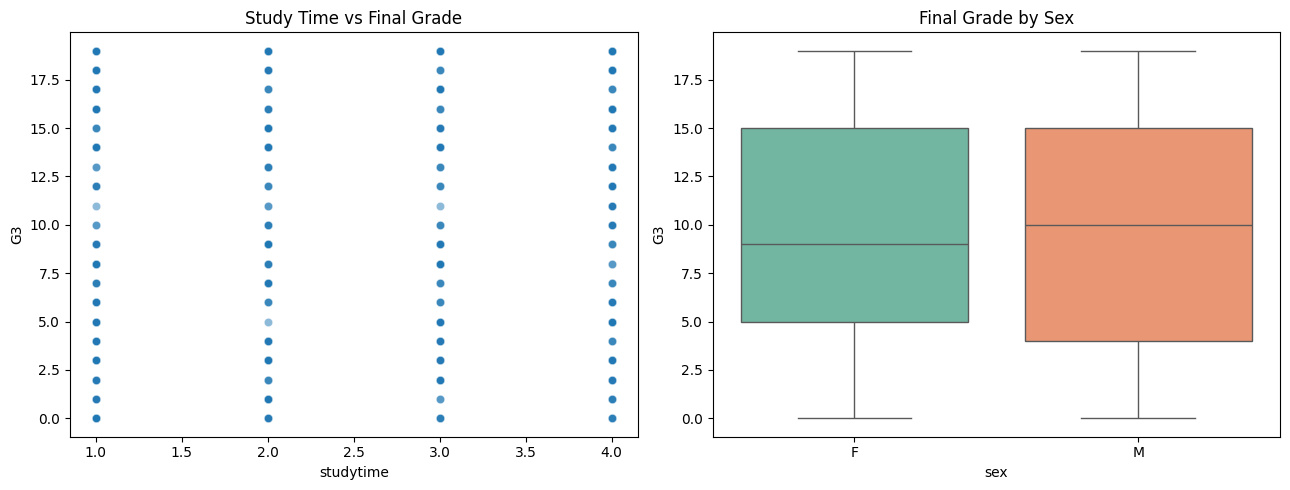

In [10]:
# Scatter matrix for grade variables
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='studytime', y='G3', alpha=0.5, ax=axes[0])
axes[0].set_title('Study Time vs Final Grade')
if 'sex' in df.columns:
    sns.boxplot(data=df, x='sex', y='G3', ax=axes[1], palette='Set2')
    axes[1].set_title('Final Grade by Sex')
plt.tight_layout()
plt.show()

### Exercise

Using the student performance DataFrame `df`:

1. Create a new binary column `passed` where G3 >= 10.
2. Calculate the pass rate overall and by sex.
3. Plot a bar chart showing mean G3 by study time level.
4. Identify the top 3 features most correlated with G3 using the correlation matrix.

Overall pass rate: 48.9%

Pass rate by sex:
sex
F    47.3
M    50.2


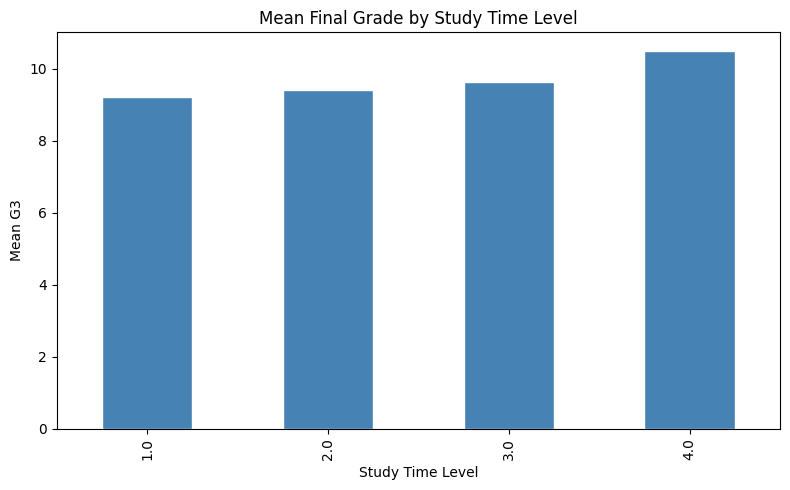


Top 3 original features most correlated with G3:
studytime    0.0778
G2           0.0634
absences    -0.0468


In [11]:
# Create the pass indicator

df['passed'] = (df['G3'] >= 10).astype(int)

overall_pass_rate = df['passed'].mean() * 100
pass_rate_by_sex = df.groupby('sex')['passed'].mean().sort_index() * 100

print(f'Overall pass rate: {overall_pass_rate:.1f}%')
print()
print('Pass rate by sex:')
print(pass_rate_by_sex.round(1).to_string())

# Mean G3 by study time level
studytime_mean = df.groupby('studytime')['G3'].mean().sort_index()
plt.figure(figsize=(8, 5))
studytime_mean.plot(kind='bar', color='steelblue', edgecolor='white')
plt.xlabel('Study Time Level')
plt.ylabel('Mean G3')
plt.title('Mean Final Grade by Study Time Level')
plt.tight_layout()
plt.show()

# Top 3 original features correlated with G3
corr_matrix = df.select_dtypes(include=np.number).corr()
g3_corr = corr_matrix['G3'].drop(['G3', 'passed'], errors='ignore')
top3_features = g3_corr.reindex(g3_corr.abs().sort_values(ascending=False).head(3).index)

print()
print('Top 3 original features most correlated with G3:')
print(top3_features.to_string(float_format=lambda x: f'{x:.4f}'))


---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*